<a href="https://colab.research.google.com/github/tdineth/Image-Processing-CO5430-4th-sem/blob/main/E_23_076_Lab_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opencv-python

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### Task 1 — View the Image as an Array of Numbers

**Explain how the pixel values relate to what you see, and why computers need to work at this level
of representation.**

An image is represented in a computer as a three-dimensional array of numerical values, where each pixel consists of intensity values for blue, green, and red channels ranging from 0 to 255. When a small 5×5 region of the image is printed, it reveals that neighboring pixels often have similar values. This similarity in numerical patterns produces smooth color transitions and shading in the visual image. On the other hand, sharp differences between adjacent pixel values correspond to edges and boundaries of objects.

This demonstrates that what humans perceive as shapes and textures are actually the result of structured numerical variations. Computers must operate at this level of representation because they cannot directly interpret visual meaning. Instead, they rely on mathematical operations applied to pixel values to detect patterns such as edges, regions, and textures. Therefore, understanding images as numerical data is fundamental for all image processing and computer vision tasks.


[[[60 70 77]
  [61 71 78]
  [68 78 85]
  [75 85 92]
  [76 84 91]]

 [[68 78 85]
  [69 79 86]
  [69 79 86]
  [65 75 82]
  [60 68 75]]

 [[67 77 84]
  [71 81 88]
  [70 80 87]
  [64 74 81]
  [57 65 72]]

 [[64 74 81]
  [67 77 84]
  [70 80 87]
  [69 79 86]
  [66 74 81]]

 [[65 75 82]
  [67 77 84]
  [60 70 77]
  [73 83 90]
  [72 80 87]]]


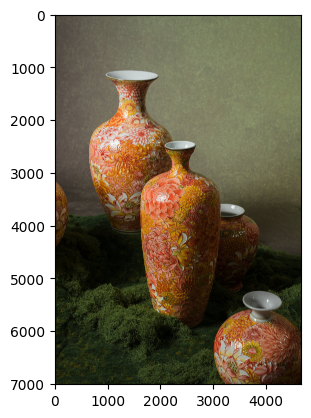

In [ ]:
img = cv2.imread("/content/drive/MyDrive/Image Processing - CO5430 - 4th sem/lab1/image.jpg") # Loads image.jpg as a NumPy array in BGR format
print(img[100:105, 100:105]) #Extracts a 5×5 pixel block starting at row 100, column 100.
# Output shape: (5, 5, 3) , Each pixel is [B, G, R] values in the range 0–255.
plt.imshow(img[:,:,::-1]) # Matplotlib expects RGB, but OpenCV gives BGR.
# reverses the last channel → converts BGR → RGB.
# Without this, our image would look blue‑tinted.

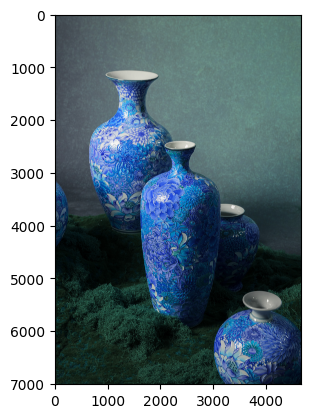

In [ ]:
plt.imshow(img)

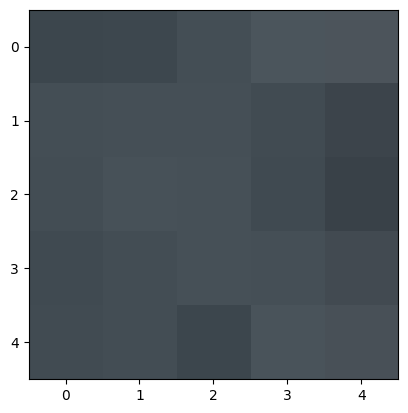

In [ ]:
plt.imshow(img[100:105, 100:105])

**If two very different images share similar numeric ranges, why do they still look different?**

Even if two images have similar ranges of pixel values, they can appear completely different because the spatial arrangement of those values is different. The structure and position of pixel intensities determine shapes, textures, and patterns. Therefore, it is not just the values themselves but how they are organized that defines the visual appearance of an image.


### Task 2 — Convert to Grayscale and Inspect Structure

**What information is lost when removing color, what is preserved, and why grayscale is the
foundation for many early-stage image processing operations.**

When the image is converted to grayscale, each pixel is represented by a single intensity value instead of three color channel values. This reduces the image from a three-dimensional array to a two-dimensional matrix. The grayscale image preserves important structural information such as shapes, edges, and brightness variations, but it removes color information.

This transformation simplifies the image while retaining key features needed for many image processing tasks. As a result, grayscale images are widely used in early stages of computer vision, such as edge detection and segmentation, where color is not essential. However, color information can be important in more advanced tasks, so grayscale is not always sufficient for all applications.


In [ ]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
"""OpenCV uses the standard luminance formula:
      𝑌 = 0.299𝑅 + 0.587𝐺 + 0.114𝐵
So each grayscale pixel is a weighted sum of the original RGB channels.
This is why grayscale values are not simple averages.

Now each pixel is a single integer (0–255):
    0 → black
    255 → white
    mid‑range → gray
"""
print(gray[100:105, 100:105]) # These numbers represent brightness, not color.

[[71 72 79 86 85]
 [79 80 80 76 69]
 [78 82 81 75 66]
 [75 78 81 80 75]
 [76 78 71 84 81]]


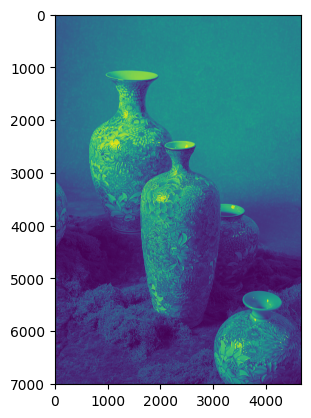

In [ ]:
# grayscale images are 2D arrays
# without a colormap, Matplotlib tries to interpret them as false‑color heatmaps
plt.imshow(gray)

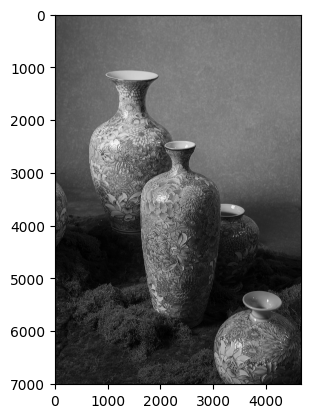

In [ ]:
plt.imshow(gray, cmap="gray")

**If grayscale simplifies computation, why don’t we always use grayscale in modern vision
systems?**

Although grayscale simplifies computation by reducing data size, modern vision systems do not always use it because color contains important information that can improve accuracy. For example, color helps distinguish objects with similar shapes but different appearances. Therefore, while grayscale is useful for simplifying analysis, color information is often necessary for more complex recognition tasks.


### Task 3 — Resize and Zoom to Study Resolution Effects

**Discuss what visual details disappear and how pixelation or blur
emerge and how reducing resolution might affect image processing tasks.**

When the image is resized to a smaller resolution, many pixel details are removed, resulting in loss of fine structures. When the reduced image is enlarged again, the missing information cannot be recovered, leading to a blurred or pixelated appearance. This demonstrates that resolution directly affects the level of detail in an image.

Reducing resolution can negatively impact image processing tasks by removing important features and making edges less distinct. However, in some cases, lower resolution can be beneficial because it reduces noise and computational cost while preserving the overall structure of the image. Therefore, resolution must be carefully chosen depending on the application.


In [ ]:
small =  cv2.resize(gray, (100,100))
big = cv2.resize(small, (500,500))

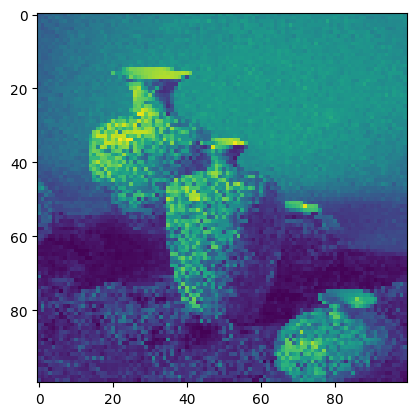

In [ ]:
plt.imshow(small)

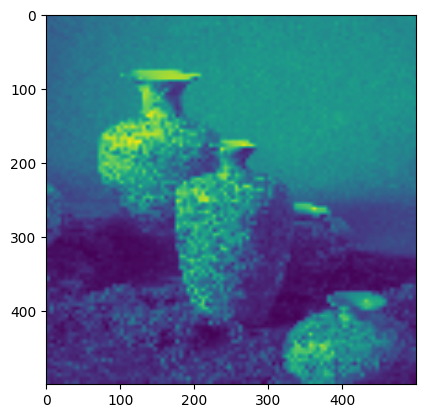

In [ ]:
plt.imshow(big)

**Can reduction of resolution ever help image processing tasks? (Hint: noise vs structure)**

Reducing resolution can sometimes help image processing tasks by removing noise and simplifying the image structure. This can make important patterns more noticeable and reduce computational complexity. However, excessive reduction may remove useful details, so a balance must be maintained.


### Task 4 — Crop to Focus on Meaningful Regions

**Explain in your report how cropping isolates
regions of interest and why spatial context sometimes matter more than isolated detail. Relate
this to face crops vs whole-scene understanding.**

Cropping extracts a specific region of the image by selecting a subset of pixels. This allows the focus to be placed on meaningful areas while removing irrelevant background information. As a result, important features within the selected region can be analyzed more clearly.

However, cropping also removes surrounding context, which may be important for understanding the full scene. For example, a cropped image of a face may be sufficient for recognition, but it does not provide information about the environment. Therefore, while cropping is useful for isolating regions of interest, it must be applied carefully to avoid losing important contextual information.



In [ ]:
crop = gray[120:220, 120:220]

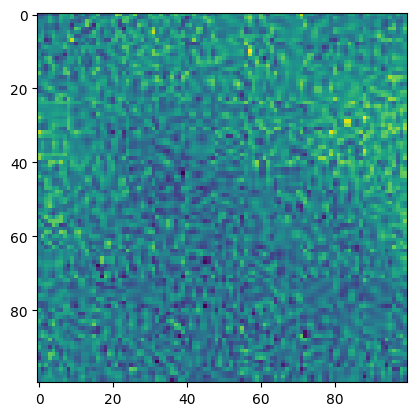

In [ ]:
plt.imshow(crop)

**Would cropping always help recognition? Or can cropping remove crucial context?**

Cropping does not always help recognition because it can remove important contextual information. Some tasks require understanding the relationship between objects and their surroundings, and excessive cropping may eliminate this information, reducing accuracy.


### Task 5 — Flip and Rotate to Explore Viewpoint Changes


**In your report, comment on
which transformations preserve interpretation and which distort meaning. Explain how viewpoint
variation relates to data augmentation and real camera motion.**

Flipping and rotating an image change the spatial arrangement of pixels, resulting in different viewpoints of the same scene. Horizontal and vertical flips create mirror images, while rotation alters the orientation. These transformations may preserve the overall structure of objects but can also change how they are perceived.

Some transformations, such as small rotations, generally preserve interpretation, while others, such as flipping text, can distort meaning. These variations are important in real-world scenarios where objects may appear in different orientations. In machine learning, such transformations are used as data augmentation techniques to improve model robustness and generalization.


In [ ]:
flip_h = cv2.flip(gray, 1) # rotate the gray scaled image around y axis (Result a mirror image)
# 1 → horizontal flip
# 0 → vertical flip
# -1 → both axes
h, w = gray.shape
cx, cy = w//2, h//2
M = cv2.getRotationMatrix2D(center=(cx,cy), angle=45, scale=1.0)
"""
This generates a 2×3 affine transform matrix that rotates the image:
    center=(cx, cy) → rotation pivot point
    angle=45 → rotate 45° counter‑clockwise
    scale=1.0 → keep original size (no zoom)
"""
rot = cv2.warpAffine(gray,M,(w,h))
# Applies the affine transform M to gray.
# (w, h) → output image size

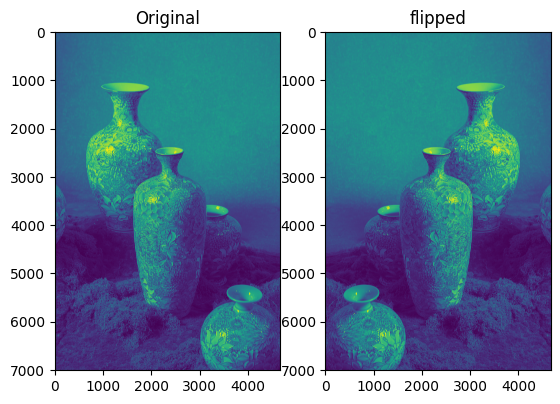

In [ ]:
plt.subplot(1,2,1)
plt.imshow(gray)
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(flip_h)
plt.title("flipped")

plt.show()

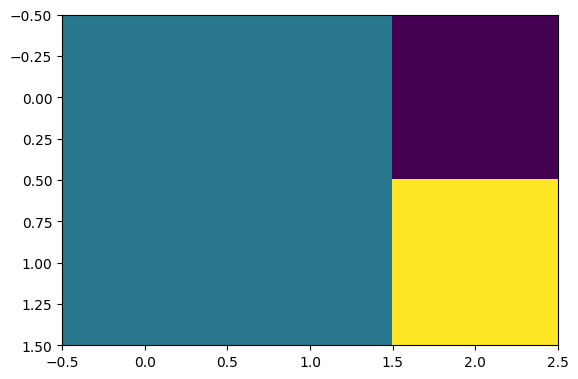

In [ ]:
plt.imshow(M)

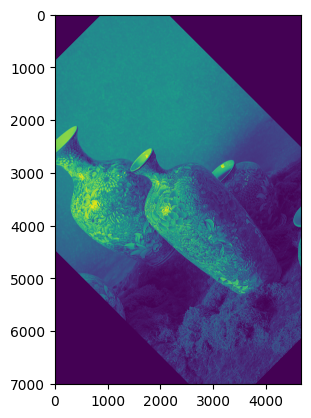

In [ ]:
plt.imshow(rot)